In [3]:
pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 8.2 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
import torch
from torch import nn
from scipy.stats import ttest_rel
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from skopt import BayesSearchCV
size_text =24
plt.rcParams.update({
    'font.family': 'serif',
    'text.usetex': False,  # Evita usar LaTeX
    'axes.titlesize': size_text,
    'xtick.labelsize': size_text,
    'ytick.labelsize': size_text,
    'legend.fontsize': size_text,
    'ytick.major.size': 2,
    'xtick.major.size': 2,
})

w = 10
h = 6

# dataset

In [5]:
df = pd.read_csv("factores_forma_uniformes_30000_R_0.1.csv")
X = df[["h", "k", "d"]].values
y = df["F"].values.reshape(-1, 1)

# Train - Test set

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data scaling

In [7]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()



X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train).ravel()
y_test_scaled = scaler_y.transform(y_test).ravel()

In [8]:
valor_d = 10
h_vals = np.linspace(-50, 50, 100)
k_vals = np.linspace(-50, 50, 100)
H, K = np.meshgrid(h_vals, k_vals)
D = np.full_like(H, valor_d)
X_pred = np.stack([H.ravel(), K.ravel(), D.ravel()], axis=1)
X_pred_scaled = scaler_X.transform(X_pred)

# Search for best hiperparameters

## Grid search

In [ ]:
X_small, _, y_small, _ = train_test_split(X_train, y_train, train_size=0.1, random_state=42)

param_grid = {
    'C': [0.1, 1,600],
    'epsilon': [0.01, 0.1],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf', 'poly']
}

grid_search = GridSearchCV(SVR(), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_small, y_small)

print("Mejores parámetros:", grid_search.best_params_)

Mejores parámetros: {'C': 600, 'epsilon': 0.01, 'gamma': 'scale', 'kernel': 'rbf'}


# Bayesian search

In [ ]:
X_small, _, y_small, _ = train_test_split(X_train, y_train, train_size=0.1, random_state=42)


search_space = {
    'C': (1e-2, 1e3, 'log-uniform'),
    'epsilon': (1e-3, 1.0, 'log-uniform'),
    'gamma': (1e-4, 1.0, 'log-uniform'),
}


opt = BayesSearchCV(
    estimator=SVR(kernel='rbf'),
    search_spaces=search_space,
    n_iter=10,
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)


opt.fit(X_small, y_small)

print("Mejores hiperparámetros encontrados:", opt.best_params_)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Mejores hiperparámetros encontrados: OrderedDict([('C', 598.9491205267932), ('epsilon', 0.1264341327263626), ('gamma', 0.30662510776734475)])


# Model training

In [9]:
modelo_svr = SVR(kernel='rbf', C=598.9491205267932, epsilon=0.1264341327263626, gamma = 0.30662510776734475)
modelo_svr.fit(X_train_scaled, y_train_scaled)


F_pred_svr_train = modelo_svr.predict(X_train_scaled)
F_pred_svr_test = modelo_svr.predict(X_test_scaled)


y_train_real = scaler_y.inverse_transform(y_train_scaled.reshape(-1, 1)).flatten()
y_test_real = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()


y_train_pred_real = scaler_y.inverse_transform(F_pred_svr_train.reshape(-1, 1)).flatten()
y_test_pred_real = scaler_y.inverse_transform(F_pred_svr_test.reshape(-1, 1)).flatten()

# Measure execution times

In [10]:
import time
t0 = time.perf_counter()

modelo_svr = SVR(kernel='rbf', C=598.9491205267932, epsilon=0.1264341327263626, gamma = 0.30662510776734475)
modelo_svr.fit(X_train_scaled, y_train_scaled)

t1 = time.perf_counter()
T_train_svr = t1 - t0

t2 = time.perf_counter()


F_pred_svr_train = modelo_svr.predict(X_train_scaled)
F_pred_svr_test = modelo_svr.predict(X_test_scaled)

t3 = time.perf_counter()
T_pred_svr = t3 - t2
N_pred_svr = X_test_scaled.shape[0]
t_pred_svr = T_pred_svr / N_pred_svr


print(f" SVR training time: {T_train_svr:.6f} s")
print(f" Total SVR prediction time (test set): {T_pred_svr:.6f} s for {N_pred_svr} samples")
print(f" SVR prediction time per sample: {t_pred_svr:.8f} s/sample")

 SVR training time: 62.956216 s
 Total SVR prediction time (test set): 1.139388 s for 7500 samples
 SVR prediction time per sample: 0.00015192 s/sample


# Metrics

## Metrics of training

In [ ]:
mse_train = mean_squared_error(y_train_real,y_train_pred_real)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train_real, y_train_pred_real)
r2_train = r2_score(y_train_real, y_train_pred_real)

print(mse_train)
print(rmse_train)
print(mae_train)
print(r2_train)

2.862943214408205e-15
5.350647824710766e-08
4.5105969040798414e-08
0.9953298171490201


## Metrics of testing

In [ ]:
mse_test = mean_squared_error(y_test_real, y_test_pred_real)
rmse_test = np.sqrt(mse_test)
mae_test = mae_train = mean_absolute_error(y_test_real, y_test_pred_real)
r2_test = r2_score(y_test_real, y_test_pred_real)

print(mse_test)
print(rmse_test)
print(mae_test)
print(r2_test)

2.8517213763470225e-15
5.340151099310789e-08
4.4871640515347184e-08
0.9952920694472719


# Mape

In [ ]:
mape = np.mean(np.abs((y_test_real - y_test_pred_real) / y_test_real)) * 100
print(f"Error porcentual promedio (MAPE): {mape:.2f}%")

Error porcentual promedio (MAPE): 3.46%


In [ ]:
tolerance = 0.05  # 5%
percentage = np.mean(np.abs((y_test_real - y_test_pred_real) / y_test_real) < tolerance) * 100
print(f"Predictions with less than 5% error: {percentage:.2f}%")

Predicciones con menos de 5% de error: 77.31%


# Learning curves

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

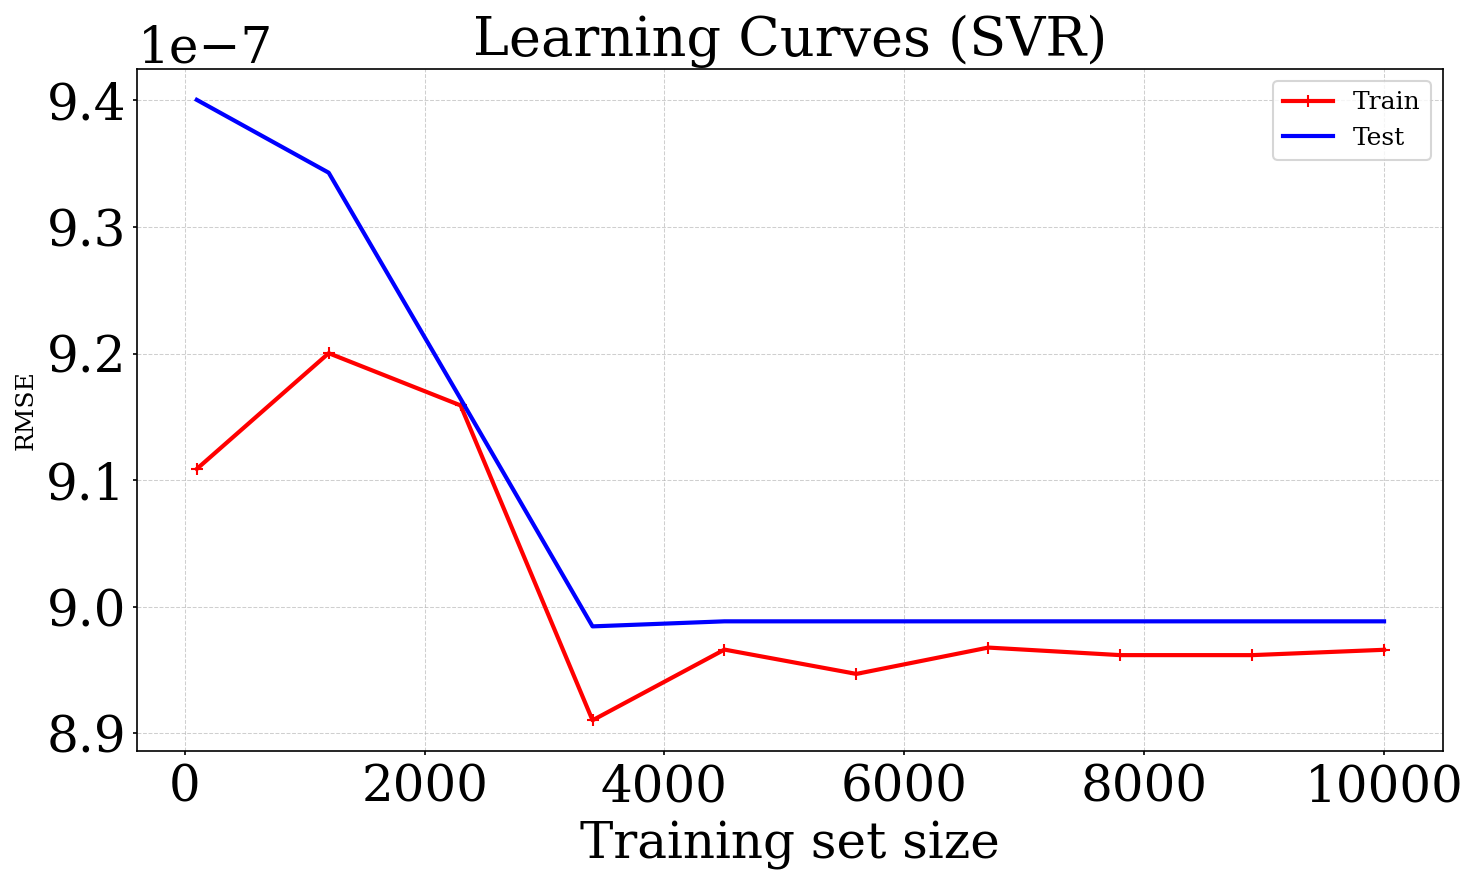

In [ ]:
def plot_learning_curves_svr_alineado(X, y, scaler_X, cv=5):

    X_sub, X_test, y_sub, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    train_sizes = np.linspace(100, 10000, 10, dtype=int)

    train_errors, val_errors = [], []

    for m in train_sizes:
        X_sample = X_sub[:m]
        y_sample = y_sub[:m]


        X_train_scaled = scaler_X.transform(X_sample)
        X_test_scaled = scaler_X.transform(X_test)

        modelo_svr = SVR(kernel='rbf', C=598.9491205267932, epsilon=0.1264341327263626, gamma = 0.30662510776734475)
        modelo_svr.fit(X_train_scaled, y_sample)


        y_train_pred = modelo_svr.predict(X_train_scaled)
        y_test_pred = modelo_svr.predict(X_test_scaled)


        train_rmse = np.sqrt(mean_squared_error(y_sample, y_train_pred))
        test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

        train_errors.append(train_rmse)
        val_errors.append(test_rmse)


    fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
    ax.plot(train_sizes, train_errors, "r-+", linewidth=2, label="Train")
    ax.plot(train_sizes, val_errors, "b-", linewidth=2, label="Test")

    ax.set_title("Learning Curves (SVR)", fontsize=size_text + 2)
    ax.set_xlabel("Training set size", fontsize=size_text)
    ax.set_ylabel("RMSE", fontsize=12)
    ax.legend(fontsize=12)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)


    plt.tight_layout()
    plt.savefig("learning_curve_svr_scaled.png", dpi=400, bbox_inches='tight')
    plt.savefig("learning_curve_svr_scaled.pdf", dpi=400, bbox_inches='tight')
    plt.savefig("learning_curve_svr_scaled.eps", dpi=400, bbox_inches='tight')
    plt.show()

plot_learning_curves_svr_alineado(X, y, scaler_X, cv=5)

# Heatmap of predictions

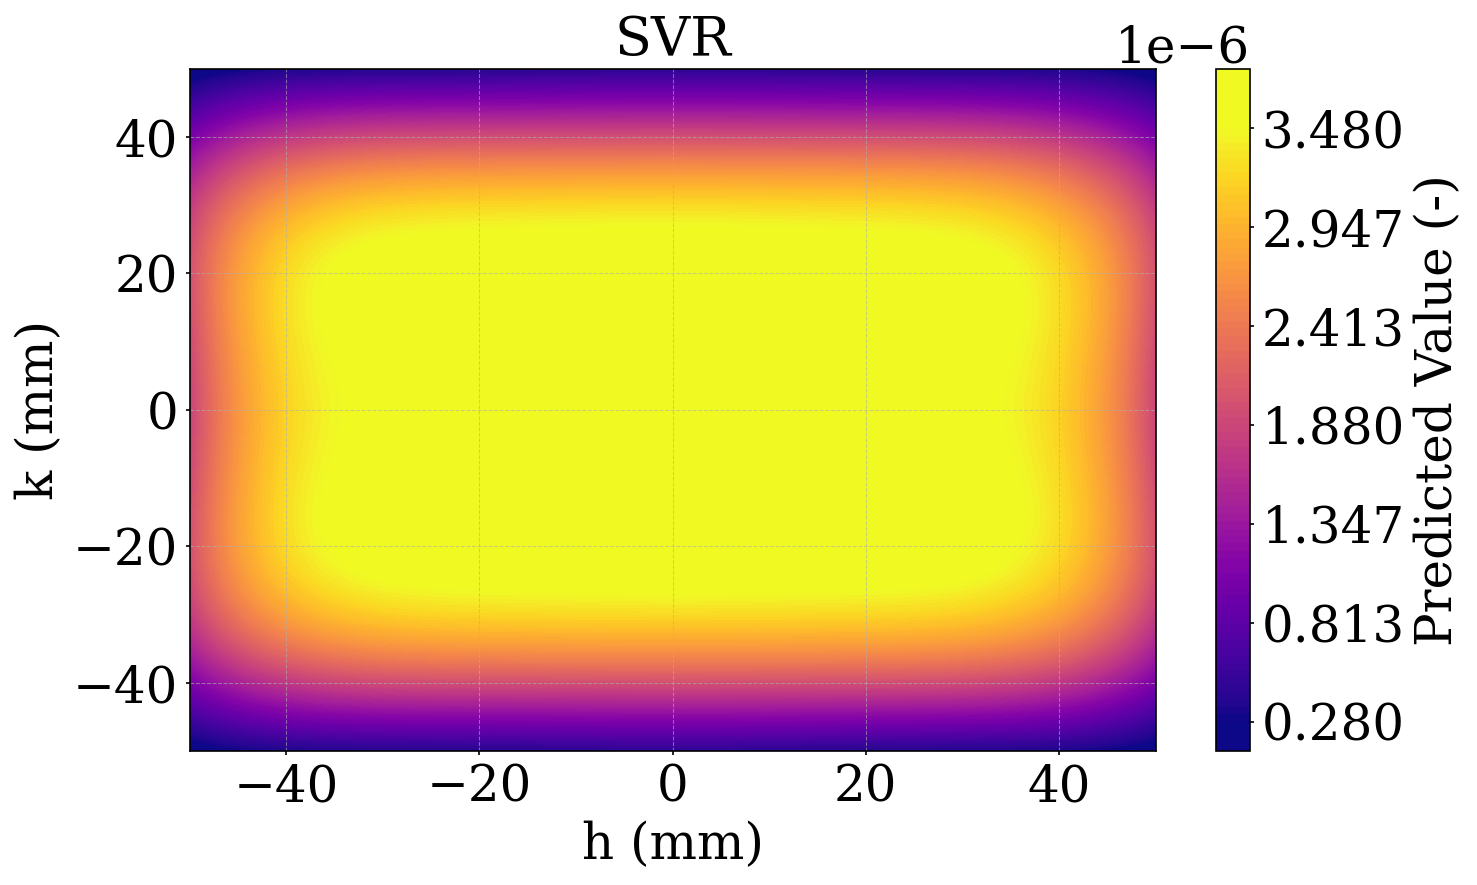

In [ ]:
valor_d = 10
h_vals = np.linspace(-50, 50, 100)
k_vals = np.linspace(-50, 50, 100)

H, K = np.meshgrid(h_vals, k_vals)
D = np.full_like(H, valor_d)


X_pred = np.stack([H.ravel(), K.ravel(), D.ravel()], axis=1)

X_pred_scaled = scaler_X.transform(X_pred)
F_pred_scaled = modelo_svr.predict(X_pred_scaled)
F_pred = scaler_y.inverse_transform(F_pred_scaled.reshape(-1, 1))
F_pred = F_pred.reshape(H.shape)


vmin = 0.28e-6
vmax = 3.48e-6
ticks = np.linspace(vmin, vmax, 7)

fig, ax = plt.subplots(1, 1, figsize=(w, h), dpi=150)

contour = ax.contourf(H, K, F_pred, levels=100, vmin=vmin, vmax=vmax, cmap='plasma')
cbar = fig.colorbar(contour)
cbar.set_label(label='Predicted Value (-)', size=size_text)
cbar.set_ticks(ticks)

ax.set_title("SVR", fontsize=size_text + 2)
ax.set_xlabel("h (mm)", fontsize=size_text)
ax.set_ylabel("k (mm)", fontsize=size_text)

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
plt.tight_layout()

plt.savefig("Heatmap_svr_predictions.png", dpi=400, bbox_inches='tight')
plt.savefig("Heatmap_svr_predictions.pdf", dpi=400, bbox_inches='tight')
plt.savefig("Heatmap_svr_predictions.eps", dpi=400, bbox_inches='tight')
plt.show()